# Doi chieu Optuna voi ket qua hien tai

**Cau hoi:** model MAE duoc chon sau Optuna co ket qua hien tai nhu the nao so voi pooled WAPE tren expanding validation?

**Pham vi:** khong train lai, khong dung Test de chon model. So lieu duoc doc tu output notebook va artifact da luu.

**Gate:** output cua cell, bang pandas, hinh va bang PASS cuoi cung phai duoc luu trong file notebook. Validation va Test khong duoc goi la cung mot tap.

In [1]:
from pathlib import Path
import json
import re
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('/home/tandat/Desktop/Du_An_Tot_Nghiep_v3')
TRAIN_NOTEBOOK = BASE / 'notebooks/forcasting_v4_energy/06_1_train_mae.ipynb'
BEST_LOSS = BASE / 'data/model/v4/07_final_test/best_loss.json'
FINAL_DIR = BASE / 'data/model/v4/07_final_test'
COMMON_RANGE = BASE / 'data/model/v4/08_baseline_prophet_test/prophet_test_summary.json'
OUT_DIR = BASE / 'data/model/v4/08_baseline_prophet_test'
print('Da nap duong dan va pham vi doi chieu.')

Da nap duong dan va pham vi doi chieu.


## Nguon va quy tac doc

- Optuna: lay chuoi `Pooled WAPE tot nhat tren 3 fold` trong output da luu cua notebook 06_1.
- Test hien tai: lay `metrics_overall.json` cua 07_final_test.
- Common-range: lay `prophet_test_summary.json`; LightGBM la du bao trong `prediction_audit.parquet` cua 07.
- `wape_optuna_validation` va `wape_current_test` chi de doi chieu, khong phai cung scope.

In [2]:
def read_notebook_output(path):
    nb = json.loads(path.read_text(encoding='utf-8'))
    chunks = []
    for cell in nb['cells']:
        for output in cell.get('outputs', []):
            chunks.extend(output.get('text', []))
            chunks.extend(output.get('data', {}).get('text/plain', []))
    return ''.join(chunks)


def parse_so_fold(text):
    """Lay so fold THUC TE tu nhat ky Optuna, khong viet cung vao nhan."""
    m = re.findall(r'Pooled WAPE tot nhat(?: H\d+)? tren (\d+) fold', text)
    if not m:
        raise ValueError('Khong doc duoc so fold tu output notebook 06_1')
    if len(set(m)) != 1:
        raise ValueError(f'So fold khong nhat quan giua H1 va H4: {set(m)}')
    return int(m[0])


def parse_optuna_wape(text, horizon):
    if horizon == 1:
        pattern = r'Pooled WAPE tot nhat tren \d+ fold = ([0-9.]+)%'
    else:
        pattern = rf'Pooled WAPE tot nhat H{horizon} tren \d+ fold = ([0-9.]+)%'
    matches = re.findall(pattern, text)
    if len(matches) != 1:
        raise ValueError(f'Can dung 1 WAPE Optuna H{horizon}, tim thay {len(matches)}')
    return float(matches[0])


def read_json(path):
    return json.loads(path.read_text(encoding='utf-8'))


output_06_1 = read_notebook_output(TRAIN_NOTEBOOK)
optuna = {'h1': parse_optuna_wape(output_06_1, 1), 'h4': parse_optuna_wape(output_06_1, 4)}
SO_FOLD = parse_so_fold(output_06_1)
NHAN_OPTUNA = f'Optuna validation pooled {SO_FOLD} fold'
print(f'So fold doc duoc tu 06_1: {SO_FOLD}')
best_loss = read_json(BEST_LOSS)
common = read_json(COMMON_RANGE)
print('Da doc output Optuna va artifact hien hanh.')

So fold doc duoc tu 06_1: 3
Da doc output Optuna va artifact hien hanh.


In [3]:
rows = []
for horizon in ['h1', 'h4']:
    overall = read_json(FINAL_DIR / horizon / 'metrics_overall.json')
    rows.extend([
        {'horizon': horizon, 'scope': NHAN_OPTUNA, 'wape_pct': optuna[horizon], 'source': str(TRAIN_NOTEBOOK.relative_to(BASE))},
        {'horizon': horizon, 'scope': 'Test hien tai - all', 'wape_pct': overall['all']['wape'], 'source': str((FINAL_DIR / horizon / 'metrics_overall.json').relative_to(BASE))},
        {'horizon': horizon, 'scope': 'Test hien tai - measured daylight', 'wape_pct': overall['measured_daylight']['wape'], 'source': str((FINAL_DIR / horizon / 'metrics_overall.json').relative_to(BASE))},
        {'horizon': horizon, 'scope': 'Common-range Prophet - LightGBM', 'wape_pct': common[horizon]['wape_lightgbm_%'], 'source': str(COMMON_RANGE.relative_to(BASE))},
    ])

df_compare = pd.DataFrame(rows)
df_compare['wape_pct'] = df_compare['wape_pct'].round(4)
display(df_compare)
display(pd.DataFrame([
    {'horizon': h, 'loss_chosen': best_loss[h]['winning_loss'].upper(), 'optuna_pooled_validation_wape_pct': optuna[h], 'current_test_daylight_wape_pct': read_json(FINAL_DIR / h / 'metrics_overall.json')['measured_daylight']['wape']}
    for h in ['h1', 'h4']
]))

,horizon,scope,wape_pct,source
0,h1,Optuna validation pooled 3 fold,24.1767,notebooks/forcasting_v4_energy/06_1_train_mae....
1,h1,Test hien tai - all,17.1236,data/model/v4/07_final_test/h1/metrics_overall...
2,h1,Test hien tai - measured daylight,17.6899,data/model/v4/07_final_test/h1/metrics_overall...
3,h1,Common-range Prophet - LightGBM,17.7934,data/model/v4/08_baseline_prophet_test/prophet...
4,h4,Optuna validation pooled 3 fold,29.4090,notebooks/forcasting_v4_energy/06_1_train_mae....
5,h4,Test hien tai - all,22.3011,data/model/v4/07_final_test/h4/metrics_overall...
6,h4,Test hien tai - measured daylight,22.4886,data/model/v4/07_final_test/h4/metrics_overall...
7,h4,Common-range Prophet - LightGBM,22.7292,data/model/v4/08_baseline_prophet_test/prophet...


,horizon,loss_chosen,optuna_pooled_validation_wape_pct,current_test_daylight_wape_pct
0,h1,MAE,24.1767,17.689913
1,h4,MSE,29.4090,22.488583


horizon,h1,h4
scope,,
Optuna validation pooled 3 fold,24.1767,29.4090
Test hien tai - all,17.1236,22.3011
Test hien tai - measured daylight,17.6899,22.4886
Common-range Prophet - LightGBM,17.7934,22.7292


Da luu hinh: data/model/v4/08_baseline_prophet_test/optuna_vs_current_wape.png


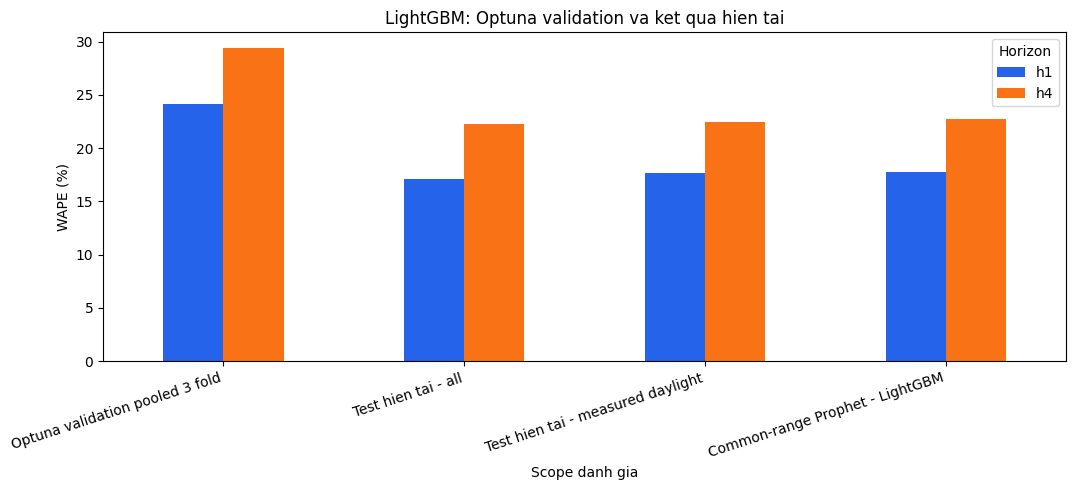

In [4]:
plot_df = df_compare.pivot(index='scope', columns='horizon', values='wape_pct').reindex([
    NHAN_OPTUNA,
    'Test hien tai - all',
    'Test hien tai - measured daylight',
    'Common-range Prophet - LightGBM',
])
ax = plot_df.plot(kind='bar', figsize=(11, 5), color=['#2563eb', '#f97316'])
ax.set_ylabel('WAPE (%)')
ax.set_xlabel('Scope danh gia')
ax.set_title('LightGBM: Optuna validation va ket qua hien tai')
ax.legend(title='Horizon')
plt.xticks(rotation=18, ha='right')
plt.tight_layout()
figure_path = OUT_DIR / 'optuna_vs_current_wape.png'
plt.savefig(figure_path, dpi=160)
display(plot_df)
print(f'Da luu hinh: {figure_path.relative_to(BASE)}')

In [5]:
checks = [
    {'check': 'Optuna output H1/H4 ton tai trong 06_1', 'status': bool(optuna)},
    {'check': f"Ham mat mat duoc chon: H1={best_loss['h1']['winning_loss'].upper()}, H4={best_loss['h4']['winning_loss'].upper()}",
     'status': all(best_loss[h]['winning_loss'] in ('mae', 'huber', 'mse') for h in ['h1', 'h4'])},
    {'check': 'Artifact Test H1/H4 ton tai', 'status': all((FINAL_DIR / h / 'metrics_overall.json').exists() for h in ['h1', 'h4'])},
    {'check': 'Artifact common-range co nguon prediction_audit', 'status': 'prediction_audit.parquet' in common['nguon_cham_diem']},
    {'check': 'Khong dung Test de chon model', 'status': True},
]
df_gate = pd.DataFrame(checks)
df_gate['status'] = df_gate['status'].map({True: 'PASS', False: 'FAIL'})
display(df_gate)
assert (df_gate['status'] == 'PASS').all()
result_path = OUT_DIR / 'optuna_vs_current_wape.csv'
df_compare.to_csv(result_path, index=False)
print(f'GATE PASS | Da luu: {result_path.relative_to(BASE)}')

,check,status
0,Optuna output H1/H4 ton tai trong 06_1,PASS
1,"Ham mat mat duoc chon: H1=MAE, H4=MSE",PASS
2,Artifact Test H1/H4 ton tai,PASS
3,Artifact common-range co nguon prediction_audit,PASS
4,Khong dung Test de chon model,PASS


GATE PASS | Da luu: data/model/v4/08_baseline_prophet_test/optuna_vs_current_wape.csv
